# QFTD_nD.ipynb

Jordan Cioni, 2026


### Loading Packages

In [1]:
# Starting timer
import time
time_0t = time.time()

# Loading qiskit packages 
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import HamiltonianGate, RXGate
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

# Misc Packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.transforms import ScaledTranslation
import matplotlib.ticker as mticker

# Setting Figure Font
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Computer modern']})
rc('text', usetex=True)




### Execution Parameters

In [2]:
# Qubits
n = 6 # x qubits
m = 6 # y qubits

# Number of Shots
num_shots = 10**8


### Problem Inputs

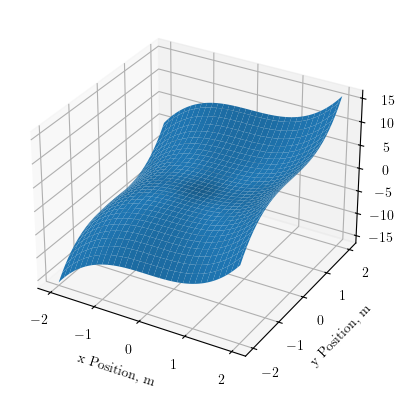

In [3]:
# Number of samples
Samples = 2**(n+m)

# Domain Inputs
xp = np.linspace(-2, 2, 2**m)
yp = np.linspace(-2, 2, 2**n)
deltaX = xp[1] - xp[0]
deltaY = yp[1] - yp[0]
X, Y = np.meshgrid(xp, yp)


# f(x,y) = cos(PiX)sin(PiY/2)
def GivenFunction(x, y):
    return (np.cos(x*2*np.pi*.5) * np.sin(y*2*np.pi*.25) )
Z = GivenFunction(X, Y)
# Theoretical Derivative
def PartialX(x, y):
    return -np.pi * np.sin(x * 2 * np.pi * .5) * np.sin(y * 2 * np.pi * .25)
def PartialY(x, y):
    return 0.5 * np.pi * np.cos(x * 2 * np.pi * .5) * np.cos(y * 2*np.pi * .25)
Zp_thX = PartialX(X, Y)
Zp_thY = PartialY(X, Y)
Zp_th_mag = np.sqrt(Zp_thX**2 + Zp_thY**2)
# Saving String
save_str = f"NdQftd_cosPiX_x_sinPion2Y"


# # f(x,y) = e^x e^y
# # Reccomended to remove outliers (See cell 13) 
# def GivenFunction(x, y):
#     return np.exp(x)*np.exp(y)
# Z = GivenFunction(X, Y)
# # Theoretical Derivative
# def PartialX(x, y):
#     return np.exp(x)*np.exp(y)
# def PartialY(x, y):
#     return np.exp(x)*np.exp(y)
# Zp_thX = PartialX(X, Y)
# Zp_thY = PartialY(X, Y)
# Zp_th_mag = np.sqrt(Zp_thX**2 + Zp_thY**2)
# # Saving String
# save_str = f"NdQftd_eXeY"


# # f(x,y) = x^3 + y^3
# # Reccomended to remove outliers (See cell 13) 
# def GivenFunction(x, y):
#     return x**3 + y**3
# Z = GivenFunction(X, Y)
# # Theoretical Derivative
# def PartialX(x, y):
#     return 3*(x**2)
# def PartialY(x, y):
#     return 3*(y**2)
# Zp_thX = PartialX(X, Y)
# Zp_thY = PartialY(X, Y)
# Zp_th_mag = np.sqrt(Zp_thX**2 + Zp_thY**2)
# # Saving String
# save_str = f"NdQftd_x3y3"


# Plotting Function
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, Y, Z)
ax.set_xlabel('x Position, m')
ax.set_ylabel('y Position, m');
ax.set_zlabel('f(x, y)')
ax.grid()


### Preparing Function Values for Initialization

In [4]:
# Arranging into vector
Z_1d =[]
for j in range(len(yp)):
    for i in range(len(xp)):
        Z_1d.append(Z[j,i])

# Getting Norm
Norm = np.sqrt(np.sum(np.array(Z_1d)**2))

# Normalizing fx
Z_1d = Z_1d/Norm
        

***
# Constructing Circuit

### Initializing

In [5]:
# Constructing x and y registers
x_reg = QuantumRegister(n, 'x')
y_reg = QuantumRegister(m, 'y')
a_reg = QuantumRegister(2, 'a')

# Creating a Quantum Circuit with n qubits, 0 classical bits
qc = QuantumCircuit(x_reg, y_reg, a_reg)

# Use built-in function to apply initial amplitudes
qc.initialize(Z_1d, x_reg[:]+y_reg[:])

### Applying QFT(s)

In [6]:
# Creating QFT Circuit
for target in range(n-1, -1, -1):
    # Apply hadamard gate
    qc.h(x_reg[target])
    qc.h(y_reg[target])
    # Iterate through controll qubits to 0
    for control in range(target-1,-1,-1):
        # Calculate r for controlled rotation
        r = target-control+1
        # Apply controlled phase (or rotation)
        qc.cp(2*np.pi/2**r, x_reg[control], x_reg[target])
        qc.cp(2*np.pi/2**r, y_reg[control], y_reg[target])
# Swap qubits
for qubit in range(n//2):
    qc.swap(x_reg[qubit], x_reg[n-qubit-1])
    qc.swap(y_reg[qubit], y_reg[n-qubit-1])

# Apply Barrier
# qc.barrier();



### Applying Wavenumber Rotations

In [7]:
# Performing controlled rotations to get that elusive sin term(s)
# Technically, we need two loops if n != m
for control in range(n):
    r = n-control
    # Appending rotation gate to each register
    qc.crx(-2*(2*np.pi/2**r), x_reg[control], a_reg[0])
    qc.crx(-2*(2*np.pi/2**r), y_reg[control], a_reg[1])

# Apply Barrier
#qc.barrier();

### Applying Inverse-QFT

In [8]:
# Apply SWAP gates to reverse
for qubit in range(n // 2):
    qc.swap(x_reg[qubit], x_reg[n-1-qubit])
    qc.swap(y_reg[qubit], y_reg[n-1-qubit])

# Apply inverse controlled phase gates and Hadamard gates
for control in range(n):
    # Iterating through targets
    for target in range(control):
        # Calculate r for controlled rotation
        r = control - target
        # Apply controlled phase rotation
        qc.cp(-np.pi / (2**r), x_reg[control], x_reg[target]) # Negative angle for inverse
        qc.cp(-np.pi / (2**r), y_reg[control], y_reg[target])
    # Apply hadamard to control
    qc.h(x_reg[control])
    qc.h(y_reg[control])

# Apply Barrier
# qc.barrier();



### Measure Circuit and Draw

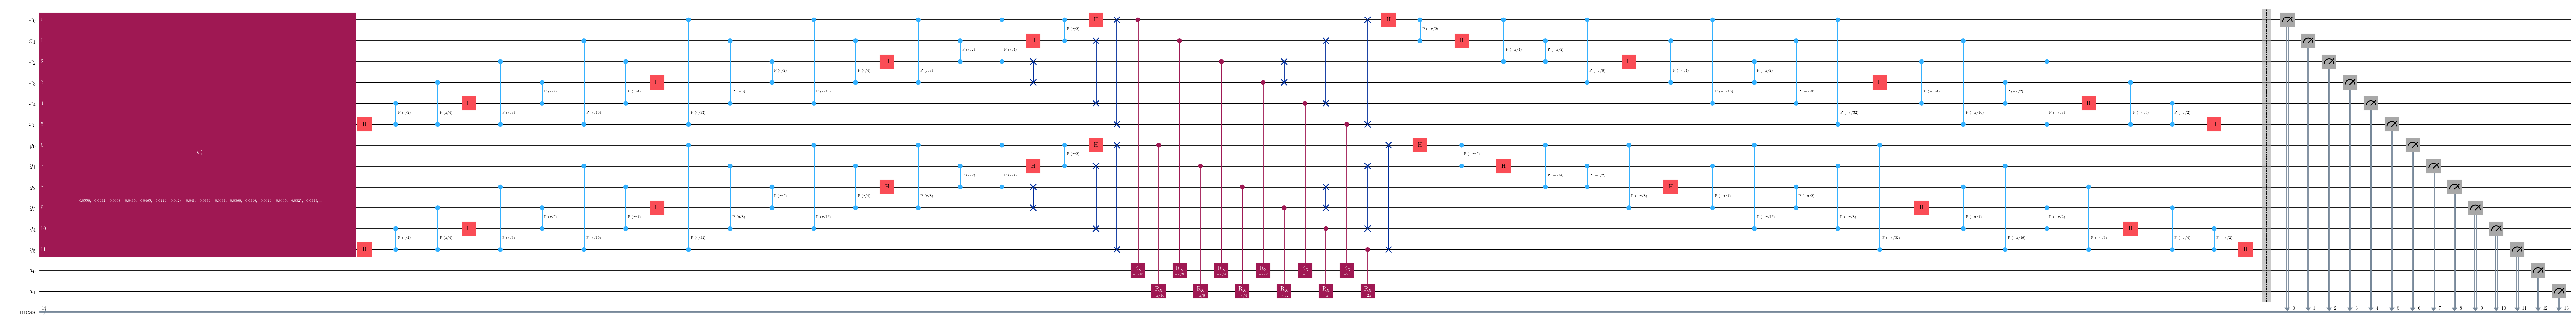

In [9]:
# Measure All Qubits
qc.measure_all()

# Draw Circuit
qc.draw('mpl', fold=-1)


***
# Executing Circuit

In [10]:
# Assigning a (simulator) "backend"
backend = AerSimulator(method='statevector', max_parallel_threads=14)

# Starting Execution Timer
time_0e = time.time()

# "Transpiling" the circuit
pm = generate_preset_pass_manager(3, backend)
qc_transpiled = pm.run(qc)

# Executing
final_job = backend.run(qc_transpiled, shots = num_shots)


### Getting Results

In [11]:
# Execution Time
ExecutionTimeString = f"Execution Time:\t{time.time()-time_0e}"
print(ExecutionTimeString)

# Getting Counts
counts = final_job.result().get_counts()

# Plotting Results
# plot_histogram(counts, figsize=(14, 7), bar_labels=False, title='n-QFTD Counts')
# Saving Graph
# fig.savefig(f"{str_save}_hist.png", format='png')

Execution Time:	48.311156272888184


***
# Analyzing Results

### Converting Bin2Int and Sorting Derivative Types

In [12]:
# Creating vector of binary state numbers
BitNames = list(counts.keys())
Pout = list(counts.values())


# Converting Binary to Interger
XYZ = []
Zout=np.zeros((2**m,2**n, 2**2))
for bn in BitNames:
    # Determine type of result from ancilla
    Type = int(bn[:2], 2) # Type= 0=>f(x,y), 1=>df/dx, 2=>df/dy, 3=>ddf/dxdy
    XYbn = bn[2:]

    # Converting to Integer
    y_dec = int(XYbn[:m], 2)
    x_dec = int(XYbn[m:], 2)

    # Appending Results
    Zout[y_dec, x_dec, Type] = counts[bn]
    XYZ.append([x_dec, y_dec, Type, counts[bn]])


### Recovering Amplitude and Removing Outliers (If Needed)

In [13]:
# Converting All Results to Probabilities
Zout = np.divide(Zout, num_shots)

# Amplitude of Partial w.r.t. x
Zout[:,:,1] = Zout[:,:,1] * ((Norm/deltaX)**2)

# Amplitude of w.r.t. y
Zout[:,:,2] = Zout[:,:,2] * ((Norm/deltaY)**2)

# Amplitude of Mixed Partial
Zout[:,:,3] = Zout[:,:,3] * ((Norm/(deltaX*deltaY))**2)

# # Removing Outliers At Edges (If Needed)
# Zout = Zout[1:-1, 1:-1, :]
# Zp_th_mag = Zp_th_mag[1:-1, 1:-1]

### Evaluating R2 (of magnitude)

In [14]:
#r2 = 1- sum[(Yactual - Yfit)^2]/sum[(Yactual-mean(Yactual))^2]

# Finding mean
meanFx = np.average(Zp_th_mag[:,:])

# Finding residuals
res = Zp_th_mag[:,:] - np.sqrt(Zout[:,:,1]+Zout[:,:,2])

# Finding total variance
var = Zp_th_mag[:,:] - meanFx

# Finding coefficient of determination
R2 = 1 - np.divide(sum(sum(res**2)), sum(sum(var**2)))

# Printing Result
print(f"R^2 = {R2}")

R^2 = -44.51913118001409


***
# Outputs

### Plotting Gradient Magnitude as 2d Image

Text(0.0, 1.0, '(b)')

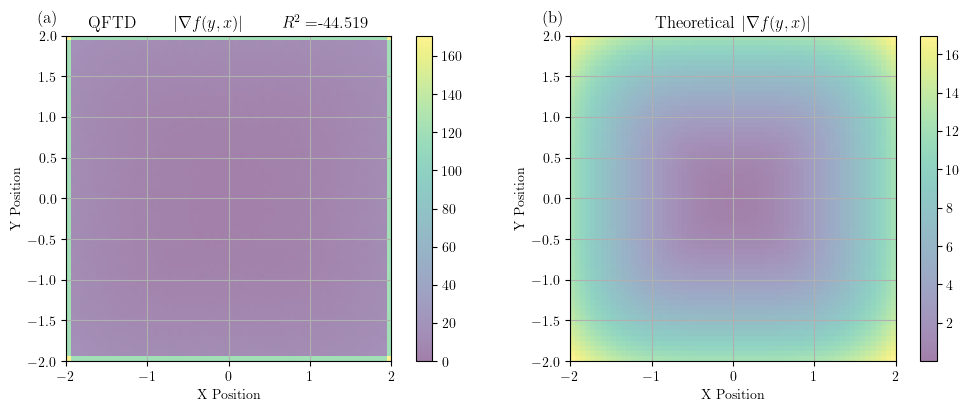

In [15]:
# Creating Figure
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(10, 4), layout="constrained")

# Must reflect Zout for image
ZoutR = Zout[::-1,:,:]
Zp_th_magR= Zp_th_mag[::-1,:]

# Plotting Quantum Results
im0 = axs[0].imshow(np.sqrt(ZoutR[:,:,1]+ZoutR[:,:,2]), 
                extent=(np.min(xp), np.max(xp), 
                        np.min(yp), np.max(yp)), alpha=0.5)
# # Formatting quantum plot
axs[0].grid()
axs[0].set_xlabel('X Position')
axs[0].set_ylabel('Y Position');
axs[0].set_title(f'QFTD    {r'$\qquad|\nabla f(y,x)|\qquad$'}    {r'$R^2 = $'}{np.round(R2, 3)}')
cb0 = plt.colorbar(im0)

# Plotting Theoretical Results
im1 = axs[1].imshow(Zp_th_magR[:,:], 
                extent=(np.min(xp), np.max(xp), 
                        np.min(yp), np.max(yp)), alpha=0.5)
# # Formatting theoretical plot
axs[1].grid()
axs[1].set_xlabel('X Position')
axs[1].set_ylabel('Y Position');
axs[1].set_title(f'Theoretical {r'$|\nabla f(y,x)|$'}')
cb1 = plt.colorbar(im1)

# Labelling Subplots
axs[0].text(
    0.0, 1.0, '(a)', transform=(axs[0].transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize='12', va='bottom')

axs[1].text(
    0.0, 1.0, '(b)', transform=(axs[1].transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize='12', va='bottom')

# # Saving
# fig.savefig(f"{save_str}_N{n}M{m}.png", format='png', dpi=1200)

### Creating Error Map

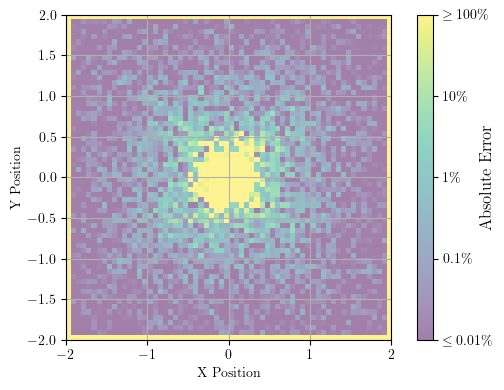

In [16]:
# Creating Figure
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(5.5, 4), layout="tight")

# Error Calculation
Error = np.abs((np.sqrt(ZoutR[:,:,1]+ZoutR[:,:,2]) - Zp_th_magR[:,:])/Zp_th_magR[:,:])
logError = np.log(Error)

# Plotting Error
im0 = axs.imshow(logError, 
                extent=(np.min(xp), np.max(xp), 
                        np.min(yp), np.max(yp)), alpha=0.5)

# # Formatting 
axs.grid()
axs.set_xlabel(r'X Position')
axs.set_ylabel('Y Position');
im0.set_clim(-4, 0)
cb0 = plt.colorbar(im0)
tick_locs=[-4, -3, -2, -1, 0]
tick_labels = [r'$\le 0.01\%$', r'$0.1\%$', r'$1\%$', r'$10\%$', r'$\ge 100\%$']
cb0.set_ticks(ticks=tick_locs, labels=tick_labels)
cb0.set_label(r'Absolute Error', size=12, labelpad=-10)

# # Saving Image
# fig.savefig(f"{save_str}_Truncated_Error_Map_N{n}M{m}.png", format='png', dpi=1200)

### Linear-Log Error Map

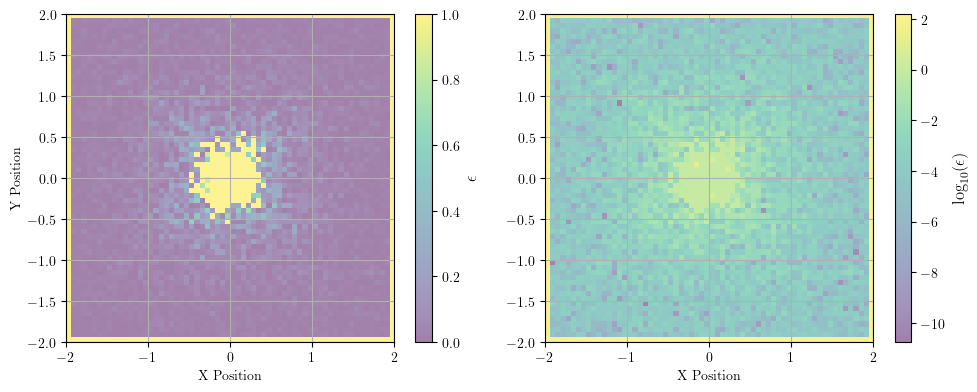

In [17]:
# Creating Figure
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(10, 4), layout="tight")

# Plotting Linear Error
im0 = axs[0].imshow(Error, 
                extent=(np.min(xp), np.max(xp), 
                        np.min(yp), np.max(yp)), alpha=0.5)
# # Formatting Linear plot
axs[0].grid()
axs[0].set_xlabel('X Position')
axs[0].set_ylabel('Y Position');
im0.set_clim(0,1)
cb0 = plt.colorbar(im0)
cb0.set_label(r'$\epsilon$', size=12)


# Plotting Log Error
im1 = axs[1].imshow(logError, 
                extent=(np.min(xp), np.max(xp), 
                        np.min(yp), np.max(yp)), alpha=0.5)
# Formatting Log Plot
axs[1].grid()
axs[1].set_xlabel('X Position')
cb1 = plt.colorbar(im1)
cb1.set_label(r'$\log_{10}(\epsilon)$', size=12)

# # Saving Figure
# fig.savefig(f"{save_str}_LinLogError_Map_N{n}M{m}.png", format='png', dpi=1200)

### Printing Stats

In [18]:
print(ExecutionTimeString)

Execution Time:	48.311156272888184
